<a href="https://colab.research.google.com/github/Saad-Naeem-891/ResNet-50-Fine-Tuning-on-CIFAR-100/blob/main/ResNet_fintuning_on_CIFAR100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt

In [ ]:
#ResNet50 default weights
weights = ResNet50_Weights.DEFAULT
transform = weights.transforms()

In [ ]:
#Dataset
full_trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

100%|██████████| 169M/169M [00:07<00:00, 22.8MB/s]


In [ ]:
# Split Data
train_size = int(0.8 * len(full_trainset))
val_size = len(full_trainset) - train_size
trainset, valset = random_split(full_trainset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

In [ ]:
# Data loaders
trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
valloader = DataLoader(valset, batch_size=64, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

In [ ]:
model = resnet50(weights=weights)

# Freeze base layers
for param in model.parameters():
    param.requires_grad = False

# Replace fully connected layer for 100 classes for our new data
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 100)

model = model.cuda()

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.fc.parameters(), lr=0.01, momentum=0.9)

train_losses = []
val_losses = []
epochs = 20

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 214MB/s]


In [ ]:
# Training and Validation optimization loop
for epoch in range(epochs):
    #Training Phase
    model.train()
    running_train_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.cuda(), labels.cuda()

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(trainloader)
    train_losses.append(avg_train_loss)

    # Validation Phase
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(valloader)
    val_losses.append(avg_val_loss)

    print(f'Epoch [{epoch + 1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

print("Finished Fine-tuning\n")

Epoch [1/20] | Train Loss: 3.0696 | Val Loss: 2.2846
Epoch [2/20] | Train Loss: 2.0649 | Val Loss: 1.9454
Epoch [3/20] | Train Loss: 1.7945 | Val Loss: 1.7991
Epoch [4/20] | Train Loss: 1.6557 | Val Loss: 1.7333
Epoch [5/20] | Train Loss: 1.5612 | Val Loss: 1.6827
Epoch [6/20] | Train Loss: 1.4822 | Val Loss: 1.6385
Epoch [7/20] | Train Loss: 1.4233 | Val Loss: 1.6078
Epoch [8/20] | Train Loss: 1.3710 | Val Loss: 1.5844
Epoch [9/20] | Train Loss: 1.3254 | Val Loss: 1.5749
Epoch [10/20] | Train Loss: 1.2862 | Val Loss: 1.5514
Epoch [11/20] | Train Loss: 1.2506 | Val Loss: 1.5417
Epoch [12/20] | Train Loss: 1.2152 | Val Loss: 1.5270
Epoch [13/20] | Train Loss: 1.1884 | Val Loss: 1.5256
Epoch [14/20] | Train Loss: 1.1587 | Val Loss: 1.5188
Epoch [15/20] | Train Loss: 1.1361 | Val Loss: 1.5098
Epoch [16/20] | Train Loss: 1.1143 | Val Loss: 1.5059
Epoch [17/20] | Train Loss: 1.0889 | Val Loss: 1.4968
Epoch [18/20] | Train Loss: 1.0641 | Val Loss: 1.5039
Epoch [19/20] | Train Loss: 1.0489 | 

--- Test Set Performance ---
Average Test Loss: 1.4716
Test Accuracy: 59.55%



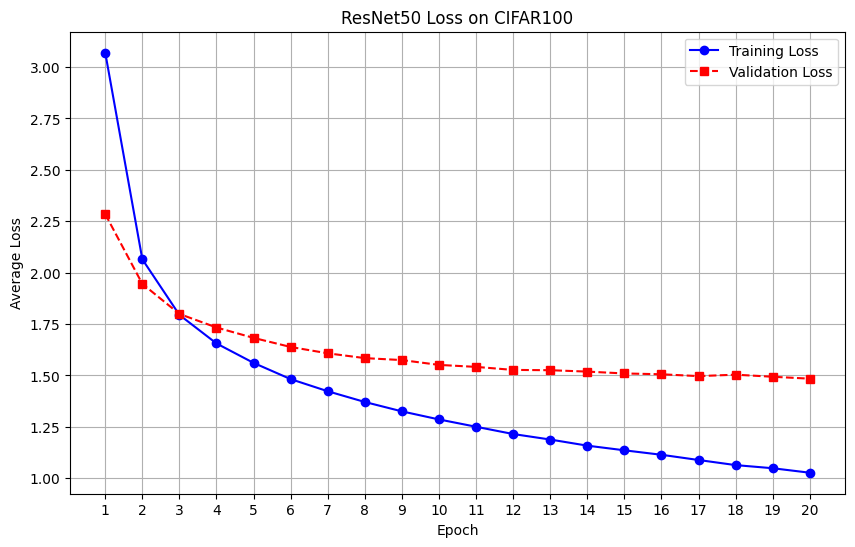

In [ ]:
# Testing Phase
model.eval()
correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.cuda(), labels.cuda()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("--- Test Set Performance ---")
print(f'Average Test Loss: {test_loss / len(testloader):.4f}')
print(f'Test Accuracy: {100 * correct / total:.2f}%\n')

# 6. Visualization
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, marker='o', linestyle='-', color='b', label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, marker='s', linestyle='--', color='r', label='Validation Loss')

plt.title('ResNet50 Loss on CIFAR100')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.xticks(range(1, epochs + 1))
plt.grid(True)
plt.legend()
plt.show()